# Simple Machine-Learning: Boosted Regression Predictions
**Author:** Eli Holmes (NOAA)</br>
Last updated: November 19, 2025

[![Colab Badge](https://img.shields.io/badge/Open_in_Colab-blue?style=for-the-badge)][colab-link] [![Download Badge](https://img.shields.io/badge/Download-grey?style=for-the-badge)][download-link] [![JupyterHub](https://img.shields.io/badge/NMFS_Jupyter_Hub-orange?style=for-the-badge)][jupyter-link] [![JupyterHub2](https://img.shields.io/badge/NOAA_Jupyter_Hub-blue?style=for-the-badge)][noaa-jupyter-link]

<!--
<a href="javascript:void(0);" onclick="openJupyterWidget('https://github.com/fish-pace/2025-tutorials/blob/main/BRT_Argo_CHLA.ipynb');">
    <img src="https://img.shields.io/badge/Open_in_JupyterHub-orange?style=for-the-badge" alt="JupyterHub Badge">
</a> 
-->

[download-link]: https://github.com/nmfs-opensci/NMFSHackDays-2026/blob/main/topics/2026-02-27/BRT_Argo_CHLA.ipynb
[colab-link]: https://colab.research.google.com/github/nmfs-opensci/NMFSHackDays-2026/blob/main/topics/2026-02-27/BRT_Argo_CHLA.ipynb
[jupyter-link]: https://nmfs-openscapes.2i2c.cloud/hub/user-redirect/lab?fromURL=https://raw.githubusercontent.com/nmfs-opensci/NMFSHackDays-2026/main/topics/2026-02-27/BRT_Argo_CHLA.ipynb
[noaa-jupyter-link]: https://noaa.nmfs-openscapes.2i2c.cloud/hub/user-redirect/lab?fromURL=https://raw.githubusercontent.com/nmfs-opensci/NMFSHackDays-2026/main/topics/2026-02-27/BRT_Argo_CHLA.ipynb

>📘 Learning Objectives
>
> 1. Understand the basics of prediction
> 2. Learn the format that your training data should be in
> 3. Learn to fit a Boosted Regression Tree
> 4. Evaluate fit
> 5. Make predictions with your model

::: {.callout-important}
# Important notes for this tutorial

### The functions are in a separate file

The Python functions for doing tasks, like prepping the data and plotting, are in a separate file `ml_utils.py` and the functions are imported with `import ml_utils as mu`. You will need to run the import code to have access to the functions.
:::

## Summary

In this tutorial we will predict a numerical variable (chl) using predictor variables, in this case hyperspectral Rrs and solar hour. Later we can add location and season. Our end goal is to create global maps of CHLA vertical profiles using Rrs hyperspectral data. CHLA vertical profiles are key to research on subsurface chlorophyll maxima, bloom structure, diel variability, and vertical migration. [Science motivation](https://fish-pace.github.io/chla-z/text_and_talks/chla_depth_talk_2.html#/title-slide)

Our training data are the in-situ measurements of surface CHLA from Bio-Argo buoys. You can see how I downloaded the Argo data and got the PACE Rrs matchups in the files `argopy.ipynb` and `argopy-matchups.ipynb`.

$$
\hat{y} \sim f(Rrs, \text{solar hour})
$$

We will use a classic non-linear prediction model: boosted regression trees (BRTs). Trees learn a big collection of if-else rules that split the response variable space. BRTs are non-linear: they can learn complicated non-linear relationships.

The goal is to create a predicted map of surface CHL given our Rrs predictor variables on a given day. We will compare to the PACE surface CHLA product, but keep in mind that these are not measuring the same thing exactly though they should be highly correlated.

![BRT pred map](https://github.com/fish-pace/2025-tutorials/blob/main/Supporting_files/simple-brt-vs-pace.png?raw=1)

## Overview of the modeling steps

1. Create your sampling dataframe: spatial samples with response (what you are trying to predict), latitude, longitude, date.
2. Create your predictor dataframe. In this example we use hyperspectral Rrs as our predictor.
3. Fit model
5. Make predictions

The hard part is the data prep. We need a dataframe that looks like this. Just showing the first 5 samples. `y` is what we are predicting and it is the true values we have (from some type of observation) and the variables to the right are what we train on. The ocean mask just tells up what to ignore (it's land).

| time       | lat   | lon   | y      | Rrs_370 | Rrs_400 | solar_hour |
| ---------- | ----- | ----- | ------ | ------- | ------- | ---------- |
| 2020-07-03 | 12.25 | 63.50 | -1.273 | 27.84   | 34.82   | 1          | 
| 2020-01-15 | 28.75 | 74.25 | -0.522 | 24.11   | 35.21   | 1          |
| 2020-03-28 | -2.00 | 88.75 | -2.004 | 29.47   | 34.55   | 8          |
| 2020-10-09 | 5.75  | 59.25 | -1.618 | 26.33   | 34.90   | 10         |
| 2020-12-22 | 17.50 | 46.50 | -0.931 | 22.88   | 35.40   | 23         |


## Variables in the model

A nice thing about BRTs is that we do not need to normalize (standardize) our predictor variables. BRTs work by splitting our predictors and normalizing has no effect. This is different than many other types of models that will perform much better with normalization.

| Feature        | Spatial Variation       | Temporal Variation | Notes                             |
|----------------|-------------------------|--------------------|-----------------------------------|
| `Rrs_wav`     | ✅ Varies by lat/lon     | ✅ Varies by time   | Numeric                |
| `solar_hour` | ❌ Same across lat/lon   | ✅ Varies by time   | Hour |
| `y` (log CHL) | ✅ Varies by lat/lon     | ✅ Varies by time   | Numeric  |


- **`Rrs`**: Hyperspectral Rrs is our core predictor variables.
  
- **`solar_hour`**: Since bio-Argo CHLA is highly affected by time of day.

- **`y` (response)**: The model trains on this. For our model it is logged CHL and it is roughly centered near 0.


## Dealing with NaNs

In our application, NaNs in y (in our case CHLA) appear when an Argo profile (a descend/ascend cycle) had no surface CHLA data. Our BRT fitting function needs us to remove any rows in our dataframe where y is NaN. We will only include profiles that have PACE Rrs data so we will not have any NaNs in our predictor variables. However BRTs functions typically filter out any training data that have NaNs in the predictor variables so we could ignore those NaNs.


## Load the libraries

* core data handling and plotting libraries
* our custom functions in `ml_utils.py`

In [ ]:
# Uncomment this line and run if you are in Colab; leave in the !. That is part of the cmd
!pip install earthaccess cartopy --quiet

In [1]:
# --- Core data handling and plotting libraries ---
import earthaccess
import xarray as xr       # for working with labeled multi-dimensional arrays
import numpy as np        # for numerical operations on arrays
import pandas as pd
import matplotlib.pyplot as plt  # for creating plots
import cartopy.crs as ccrs
import sklearn

In [2]:
# --- Custom python functions ---
import os, importlib
# Looks to see if you have the file already and if not, downloads from GitHub
if not os.path.exists("ml_utils.py"):
    !wget -q https://raw.githubusercontent.com/fish-pace/2025-tutorials/main/ml_utils.py

import ml_utils as mu
importlib.reload(mu)

<module 'ml_utils' from '/home/jovyan/2025-tutorials/ml_utils.py'>

# Load the Bio-Argo training data

In [3]:
# Load data from GitHub
import pandas as pd
import numpy as np

base_url = (
    "https://raw.githubusercontent.com/"
    "fish-pace/fish-pace-datasets/main/"
    "datasets/chla_z/data"
)
url = f"{base_url}/CHLA_argo_profiles_plus_PACE.parquet"
dataset = pd.read_parquet(url)
dataset = dataset.rename(columns={
    "LATITUDE": "lat",
    "LONGITUDE": "lon",
    "TIME": "time",
})
# Add solar_hour
dataset = mu.add_solar_time_features_df(dataset)
# Add location and seasonality variables
dataset = mu.add_spherical_coords(dataset)  # add lat/lon variables to dataset
dataset = mu.add_seasonal_time_features(dataset)

# Drop all rows with no Rrs data
rrs_cols = [c for c in dataset.columns if c.startswith("pace_Rrs_") and c[-1].isdigit()]
dataset = dataset.dropna(subset=rrs_cols, how="all").reset_index(drop=True)
dataset

,profile_id,PLATFORM_NUMBER,CYCLE_NUMBER,time,lat,lon,CHLA_0_10,CHLA_0_10_N,CHLA_10_20,CHLA_10_20_N,...,pace_chlor_a,pace_Kd_490,solar_hour,solar_sin_time,solar_cos_time,x_geo,y_geo,z_geo,sin_time,cos_time
0,4903485_0033,4903485,33,2024-03-05 01:16:05+00:00,29.082600,-17.213600,0.836414,4,0.918398,5,...,0.265202,0.0710,0.120482,0.031537,0.999503,0.834775,-0.258623,0.486070,0.899296,0.437340
1,6904240_0068,6904240,68,2024-03-05 14:48:38.036000+00:00,59.971409,-31.955397,NaN,0,NaN,0,...,0.156042,0.0590,12.680196,-0.177135,-0.984187,0.424597,-0.264858,0.865776,0.899296,0.437340
2,1902495_0002,1902495,2,2024-03-06 14:48:36.002000128+00:00,-19.579800,1.223800,0.016979,5,0.026581,5,...,0.057379,0.0356,14.891586,-0.686755,-0.726889,0.941961,0.020123,-0.335119,0.906686,0.421806
3,2903863_0040,2903863,40,2024-03-06 19:59:32.002000128+00:00,18.641800,-156.094300,0.079560,5,0.080208,5,...,0.072929,0.0372,9.585936,0.590760,-0.806847,-0.866250,-0.383972,0.319651,0.906686,0.421806
4,2902882_0079,2902882,79,2024-03-07 02:07:40+00:00,25.023887,148.098503,-0.004033,3,NaN,0,...,0.053397,0.0362,12.001011,-0.000265,-1.000000,-0.769267,0.478855,0.422996,0.913808,0.406147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2765,7902313_0013,7902313,13,2025-11-29 07:43:45.000999936+00:00,-17.754400,2.040700,0.451718,5,0.451718,5,...,0.212636,0.0690,7.865213,0.883126,-0.469136,0.951768,0.033913,-0.304937,-0.526755,0.850017
2766,2903797_0142,2903797,142,2025-11-29 10:28:21.012999936+00:00,36.626787,16.598343,NaN,0,0.061200,1,...,0.179413,0.0702,11.579056,0.109980,-0.993934,0.769098,0.229254,0.596600,-0.526755,0.850017
2767,4903848_0034,4903848,34,2025-11-29 10:44:19.032000+00:00,36.987721,15.660888,NaN,0,NaN,0,...,0.196828,0.0738,11.782670,0.056866,-0.998382,0.769111,0.215621,0.601644,-0.526755,0.850017
2768,5907146_0031,5907146,31,2025-11-29 10:46:20.028000+00:00,43.151892,7.472692,NaN,0,NaN,0,...,0.277865,0.1052,11.270402,0.189849,-0.981813,0.723347,0.094880,0.683935,-0.526755,0.850017


Here are where the samples are.

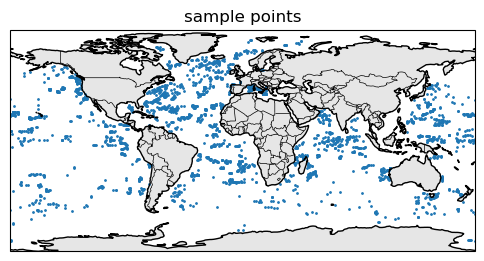

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(
    figsize=(6, 4),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# coarse coastlines
ax.coastlines(resolution="110m")
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="0.9")
ax.scatter(dataset.lon, dataset.lat, s=1, transform=ccrs.PlateCarree())
ax.set_title("sample points")
plt.show()

## Create the train-test dataset

We will use `sklearn`'s split function.

In [5]:
from sklearn.model_selection import train_test_split

# rs columns: pace_Rrs_* ending in a digit
y_col = "CHLA_0_10"
rrs_cols = [
    c for c in dataset.columns
    if c.startswith("pace_Rrs_") and c[-1].isdigit()
]
# if you want to try with more variables 
#extra = ["solar_hour", "x_geo", "y_geo", "z_geo"]
extra = ["solar_hour"]
train_data = dataset[["time", "lat", "lon", y_col] + rrs_cols + extra]
train_data = train_data.rename(columns={y_col: "y"})

# IMPORTANT! log our response so it is symmetric (Normal-ish)
train_data = train_data.where(train_data["y"] > 0)
train_data["y"] = np.log10(train_data["y"])
train_data = train_data.dropna(subset=["y"]) # drop nan

y = train_data["y"]  # target
X = train_data[rrs_cols + extra]  # predictors

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42, # change for a new random train set
)

## Fit a BRT

In [6]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

brt_model = HistGradientBoostingRegressor(
    max_depth=6, learning_rate=0.05, max_iter=400,
    validation_fraction=0.1, early_stopping=True, random_state=42
).fit(X_train, y_train)

## Make a prediction and plot residuals

In [7]:
y_pred = brt_model.predict(X_train)
residuals = y_train - y_pred
df_map = train_data.loc[y_train.index, ["lat", "lon", "time"]]
df_map["y"] = y_train
df_map["y_pred"] = y_pred
df_map["residual"] = residuals

In [8]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def residual_plot(df_map):
    fig, ax = plt.subplots(
        figsize=(7,5),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )
    # symmetric limits around 0
    res = df_map["residual"].values
    max_abs = np.nanmax(np.abs(res))
    vmin, vmax = -max_abs, max_abs

    ax.coastlines(resolution="110m")
    ax.add_feature(cfeature.LAND, facecolor="0.9")

    sc = ax.scatter(
        df_map["lon"],
        df_map["lat"],
        c=df_map["residual"],
        cmap="coolwarm",
        s=6,
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    plt.colorbar(sc, ax=ax, label="Residual (y - y_pred)")
    bias = df_map["residual"].mean()
    plt.title(f"Residual Map (mean bias = {bias:.3f})")
    plt.show()


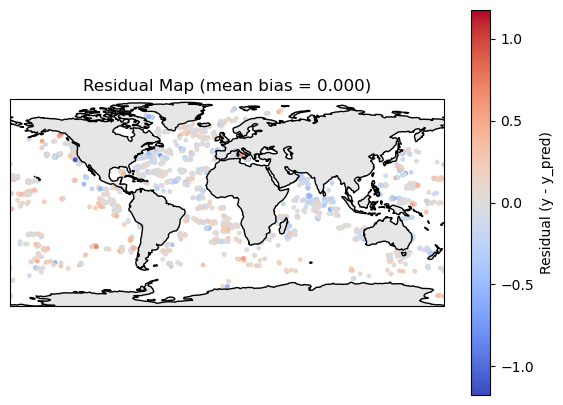

In [13]:
residual_plot(df_map)

## Compare to the test data

In [9]:
y_pred = brt_model.predict(X_test)
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("bias:", np.mean(y_test - y_pred))

R²: 0.7330792741945183
RMSE: 0.3427451647611817
bias: -0.056228825385024044


### Make a scatter plot

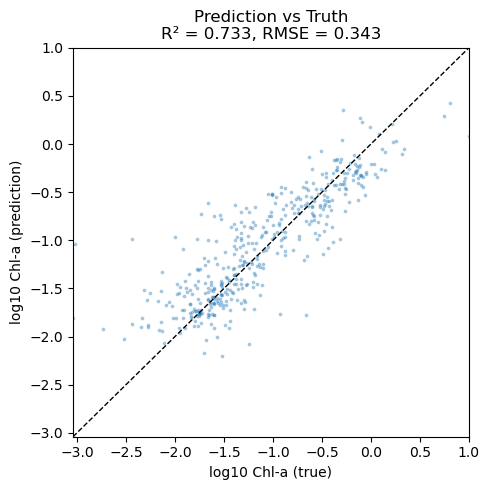

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

y_true = y_test

# Compute some metrics
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# Scatter plot
plt.figure(figsize=(5, 5))
plt.scatter(y_true, y_pred, s=3, alpha=0.3)

# 1:1 line
lims = [
    min(y_true.min(), y_pred.min()),
    max(y_true.max(), y_pred.max())
]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("log10 Chl-a (true)")
plt.ylabel("log10 Chl-a (prediction)")
plt.title(f"Prediction vs Truth\nR² = {r2:.3f}, RMSE = {rmse:.3f}")
plt.tight_layout()
plt.show()

### Plot residuals

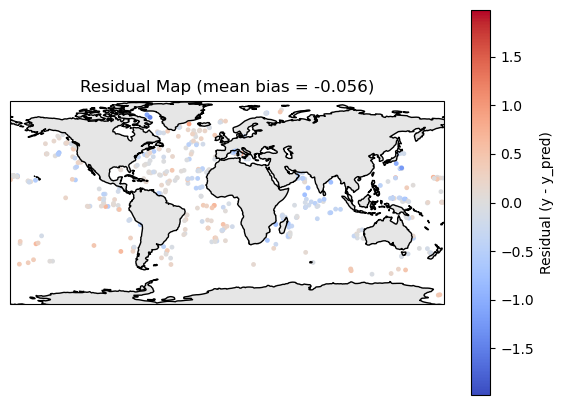

In [11]:
y_pred = brt_model.predict(X_test)
residuals = y_test - y_pred
df_map = train_data.loc[y_test.index, ["lat", "lon", "time"]]
df_map["y"] = y_test
df_map["y_pred"] = y_pred
df_map["residual"] = residuals
residual_plot(df_map)

## Make a prediction of the whole region

To make a prediction, we use the `predict` attribute for the brt model object. It needs the predictor variables in rows rather than like a lat/lon map and we need to deal with all the NaNs in Rrs data. I create 2 functions:
* `make_prediction()` takes a xarray DataArray of Rrs. So like `ds["Rrs"]`.
* `make_plot()` takes a xarray DataArray of predictions from `make_prediction()` and optionally a data array of chla to compare to our predictions. So like `ds["chlora"]`.


In [12]:
# Function 1 takes a xarray dataset from PACE with Rrs
import xarray as xr
def make_prediction(R: xr.Dataset, brt_model, feature_cols, solar_const=0):
    # --- 3. Stack lat/lon into a single "pixel" dimension ---
    R2 = R.stack(pixel=("lat", "lon"))  # (pixel, wavelength)
    R2 = R2.transpose("pixel", "wavelength")
    # Load this subset into memory
    R2_vals = R2.values  # shape: (n_pixel, n_wavelength)

    # --- 4. Make predictions dataframe
    # If the model expects solar_hour, add it as a constant column
    if "solar_hour" in feature_cols:
        wave_cols = [c for c in feature_cols if c != "solar_hour"]
        df_pred = pd.DataFrame(R2_vals, columns=wave_cols)
        df_pred["solar_hour"] = solar_const
        df_pred = df_pred[feature_cols]
    else:
        df_pred = pd.DataFrame(R2_vals, columns=feature_cols)

    # --- 5. Handle NaNs: BRTs generally cannot handle NaNs in predictors ---
    # Rrs dataset will have loads of NaNs
    valid_mask = ~df_pred.isna().any(axis=1)  # pixels with all bands present
    df_valid = df_pred[valid_mask]

    # Prepare an array for predictions (fill NaNs where we cannot predict)
    y_pred_flat = np.full(df_pred.shape[0], np.nan, dtype=float)

    # --- 6. Predict on the valid pixels ---
    if len(df_valid) > 0:
        y_pred_flat[valid_mask.values] = brt_model.predict(df_valid)

    # --- 7. Reshape back to (lat, lon) ---
    nlat = R.sizes["lat"]
    nlon = R.sizes["lon"]
    pred_map = y_pred_flat.reshape(nlat, nlon)

    pred_da = xr.DataArray(
        pred_map,
        coords={"lat": R["lat"], "lon": R["lon"]},
        dims=("lat", "lon"),
        name="y_pred"
    )

    return pred_da

In [13]:
# Function 2 takes an xarray dataarray of our predictions and makes a map
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def make_plot(
    brt_da: xr.DataArray,
    pace_da: xr.DataArray | None = None,
    diff: bool = True,
    shared_colorbar: bool = True,
    pace_label: str = "PACE Chlorophyll",
    brt_label: str = "BRT prediction",
    cmap_brt: str = "viridis",
):
    """
    Plot prediction, optionally with PACE and difference.

    Parameters
    ----------
    brt_da : xr.DataArray
        BRT Prediction on a lat/lon grid.
    pace_da : xr.DataArray or None
        PACE chlor_a on the same lat/lon grid. If None, only brt is plotted.
    diff : bool, default True
        If True and pace_da is provided, add a third panel with pace - brt.
    shared_colorbar : bool, default True
        If True, use one colorbar for truth+prediction panels.
    """
    # -----------------------
    # Case 1: only prediction
    # -----------------------
    if pace_da is None:
        # robust-ish limits from prediction only
        vals = brt_da.values.ravel()
        vmin, vmax = np.nanpercentile(vals, (0, 100))

        fig, ax = plt.subplots(
            1, 1,
            figsize=(6, 4),
            subplot_kw={"projection": ccrs.PlateCarree()},
            constrained_layout=True,
        )

        ax.coastlines()
        ax.add_feature(cfeature.LAND, facecolor="0.9")

        im = ax.pcolormesh(
            brt_da["lon"],
            brt_da["lat"],
            brt_da,
            transform=ccrs.PlateCarree(),
           vmin=vmin, vmax=vmax,
            cmap=cmap_brt,
        )

        ax.set_title(brt_label)
        cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.06, pad=0.08)
        cbar.set_label(brt_label)
        plt.show()
        return

    # ------------------------------------------------
    # Case 2: truth + prediction (+/- difference)
    # ------------------------------------------------
    if diff:
        ncols = 3
    else:
        ncols = 2

    fig, axs = plt.subplots(
        1, ncols,
        figsize=(5 * ncols, 5),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True,
    )

    if ncols == 1:
        axs = [axs]  # just in case, but here ncols>=2

    # 1. Compute robust-ish limits for truth & prediction
    all_vals = np.concatenate([
        pace_da.values.ravel(),
        brt_da.values.ravel()
    ])
    vmin, vmax = np.nanpercentile(all_vals, (0, 100))

    # -------------------
    # Panel 1: pace
    # -------------------
    ax = axs[0]
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="0.9")
    im_pace = ax.pcolormesh(
        pace_da["lon"],
        pace_da["lat"],
        pace_da,
        transform=ccrs.PlateCarree(),
        vmin=vmin, vmax=vmax,
        cmap=cmap_brt,
    )
    ax.set_title(pace_label)

    # -------------------
    # Panel 2: brt
    # -------------------
    ax = axs[1]
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="0.9")
    im_brt = ax.pcolormesh(
        brt_da["lon"],
        brt_da["lat"],
        brt_da,
        transform=ccrs.PlateCarree(),
        vmin=vmin, vmax=vmax,
        cmap=cmap_brt,
    )
    ax.set_title(brt_label)

    # -------------------
    # Panel 3: Difference (optional)
    # -------------------
    if diff:
        diff_da = pace_da - brt_da

        # Symmetric limits for diff
        diff_vals = diff_da.values.ravel()
        diff_max = np.nanpercentile(np.abs(diff_vals), 98)
        diff_vmin, diff_vmax = -diff_max, diff_max

        ax = axs[2]
        ax.coastlines()
        ax.add_feature(cfeature.LAND, facecolor="0.9")
        im_diff = ax.pcolormesh(
            diff_da["lon"],
            diff_da["lat"],
            diff_da,
            transform=ccrs.PlateCarree(),
            vmin=diff_vmin,
            vmax=diff_vmax,
            cmap="coolwarm",
        )
        ax.set_title("PACE - BRT")

    # -------------------
    # Colorbars
    # -------------------
    if shared_colorbar:
        # one shared colorbar for pace + brt
        cbar1 = fig.colorbar(
            im_brt,
            ax=axs[:2],
            orientation="horizontal",
            fraction=0.05,
            pad=0.08,
        )
        cbar1.set_label("Value")
    else:
        # separate colorbars for PACE and BRT
        cbar_t = fig.colorbar(
            im_pace,
            ax=axs[0],
            orientation="horizontal",
            fraction=0.05,
            pad=0.08,
        )
        cbar_t.set_label(pace_label)

        cbar_p = fig.colorbar(
            im_brt,
            ax=axs[1],
            orientation="horizontal",
            fraction=0.05,
            pad=0.08,
        )
        cbar_p.set_label(brt_label)

    if diff:
        cbar2 = fig.colorbar(
            im_diff,
            ax=axs[-1],
            orientation="horizontal",
            fraction=0.05,
            pad=0.08,
        )
        cbar2.set_label("PACE - BRT")

    plt.show()


## Load PACE Rrs and Chla data

* Authenticate
* Search
* Open dataset

In [14]:
import earthaccess
import xarray as xr

day = "2024-07-08"

auth = earthaccess.login()
# are we authenticated?
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)

# Get Rrs
rrs_results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_RRS",
    temporal = (day, day),
    granule_name="*.DAY.*.4km.nc"
)
f = earthaccess.open(rrs_results[0:1], pqdm_kwargs={"disable": True})
rrs_ds = xr.open_dataset(f[0])

# Get chla
chl_results = earthaccess.search_data(
    short_name = "PACE_OCI_L3M_CHL",
    temporal = (day, day),
    granule_name="*.DAY.*.4km.nc"
)
f = earthaccess.open(chl_results[0:1], pqdm_kwargs={"disable": True})
chl_ds = xr.open_dataset(f[0])
chl_ds["log10_chla"] = np.log10(chl_ds["chlor_a"])

## Make a prediction for North Atlantic

In [20]:
# Northwest Atlantic
# Set a box
lat_min, lat_max = 30, 60
lon_min, lon_max = -60, -40
# Get Rrs for that box
R = rrs_ds["Rrs"].sel(
    lat=slice(lat_max, lat_min),   # decreasing lat coord: max→min
    lon=slice(lon_min, lon_max)
)
R = R.transpose("lat", "lon", "wavelength")

# Get CHLA for that box
chla = chl_ds["log10_chla"].sel(
    lat=slice(lat_max, lat_min),   # decreasing lat coord: max→min
    lon=slice(lon_min, lon_max)
)
chla = chla.transpose("lat", "lon")

In [21]:
%%time
# Make prediction
feature_cols = list(X_train.columns)
pred_da = make_prediction(R, brt_model, feature_cols, solar_const=0)

CPU times: user 5.19 s, sys: 549 ms, total: 5.74 s
Wall time: 5.25 s


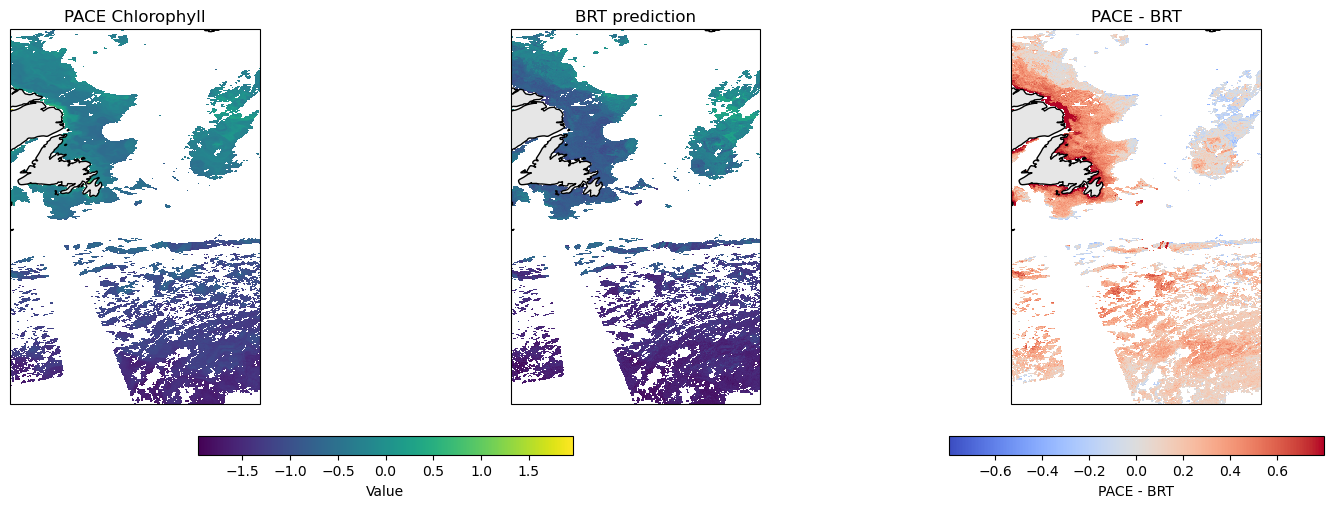

In [22]:
# Make a plot
make_plot(pred_da, chla)

## Scatter plot of PACE versus BRT

Note, BRT average CHLA in the 0 to 10m and PACE are not measuring exactly the same thing. PACE chlor_a uses ratios of Rrs wavelengths and Rrs reflectance 'sees' deeper in the water column than 10m. So we would expect that PACE chlor_a is larger than CHLA_0_10 when chlorophyll is low. The bio-Argo floats tend to be in deeper water and do not see high chlorophyll levels that one sees in coastal and near-shore. There are few CHLA_0_10 values above 0 (log10 scale). Thus it is not surprising that the BRT and PACE data are very different above 0 --- the BRT model had no opportunity to "learn" the Rrs pattern for high chlorophyll.

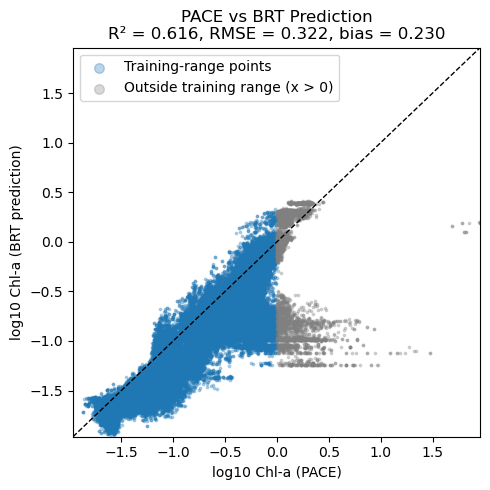

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# Flatten and drop NaNs
y_pace = chla.values.ravel()
y_pred = pred_da.values.ravel()

mask = np.isfinite(y_pace) & np.isfinite(y_pred)
y_pace = y_pace[mask]
y_pred = y_pred[mask]

# Metrics
r2 = r2_score(y_pace, y_pred)
rmse = np.sqrt(mean_squared_error(y_pace, y_pred))
bias = np.mean(y_pace - y_pred)

# Split by x > 0
mask_x_pos = y_pace > 0

x_pos = y_pace[mask_x_pos]
y_pos = y_pred[mask_x_pos]

x_nonpos = y_pace[~mask_x_pos]
y_nonpos = y_pred[~mask_x_pos]

# Plot
plt.figure(figsize=(5, 5))

# Training-range points
plt.scatter(
    x_nonpos, y_nonpos, 
    s=3, alpha=0.3, label="Training-range points"
)

# Out-of-range (x > 0)
plt.scatter(
    x_pos, y_pos, 
    s=3, alpha=0.3, color="grey", label="Outside training range (x > 0)"
)

# 1:1 line
lims = [
    min(y_pace.min(), y_pred.min()),
    max(y_pace.max(), y_pred.max())
]
plt.plot(lims, lims, "k--", linewidth=1)

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("log10 Chl-a (PACE)")
plt.ylabel("log10 Chl-a (BRT prediction)")
plt.title(
    f"PACE vs BRT Prediction\n"
    f"R² = {r2:.3f}, RMSE = {rmse:.3f}, bias = {bias:.3f}"
)

plt.legend(loc="upper left", markerscale=4)
plt.tight_layout()
plt.show()



## Summary

You have fit a basic BRT to predict surface CHLA using bio-argo data. Things you might try

* add location and season to your model
* remove solar_hour